# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/9/2026

In [19]:
# Your Phase 1 solution to the problem goes here.


[Q1, page 1](https://drive.google.com/file/d/1q4pELHpJ85ZYoxrS3jPakiGhCebBPigD/view)
[Q2, page 2](https://drive.google.com/file/d/1sZKHYTdZMKFpi8xlufioHytOxUz5VjGa/view)


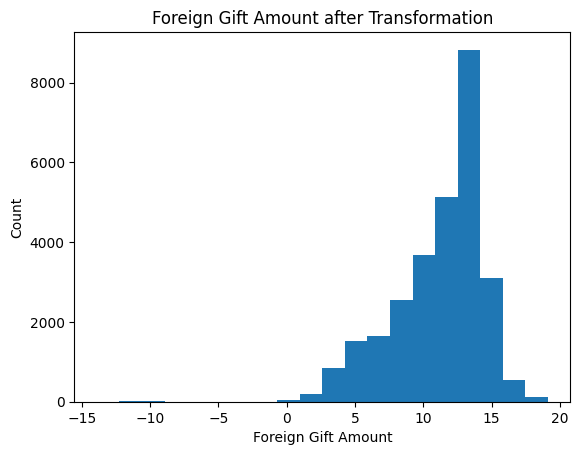

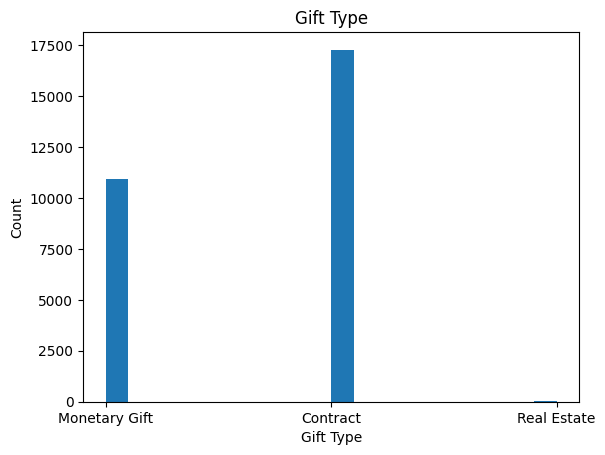


Proportion of Monetary Gifts as a %: 38.75
Proportion of Contract Gifts as a %: 61.21
Proportion of Real Estate Gifts as a %: 0.04


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


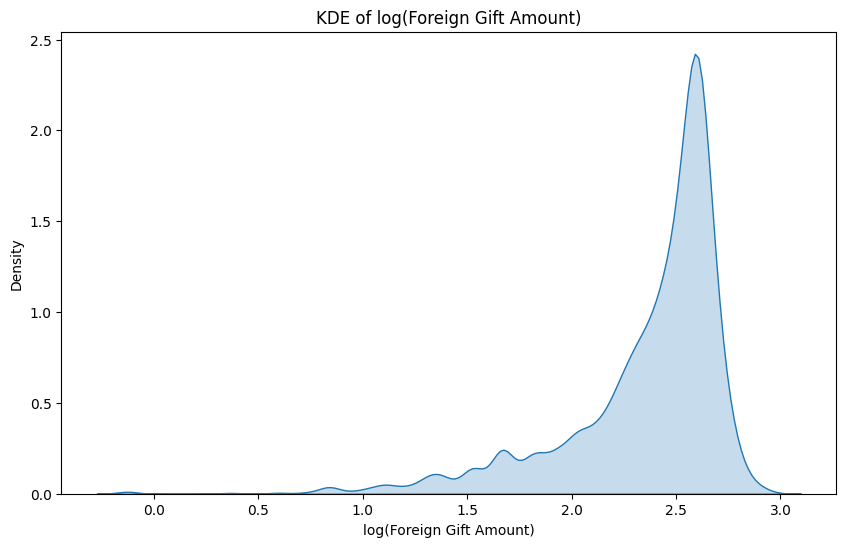

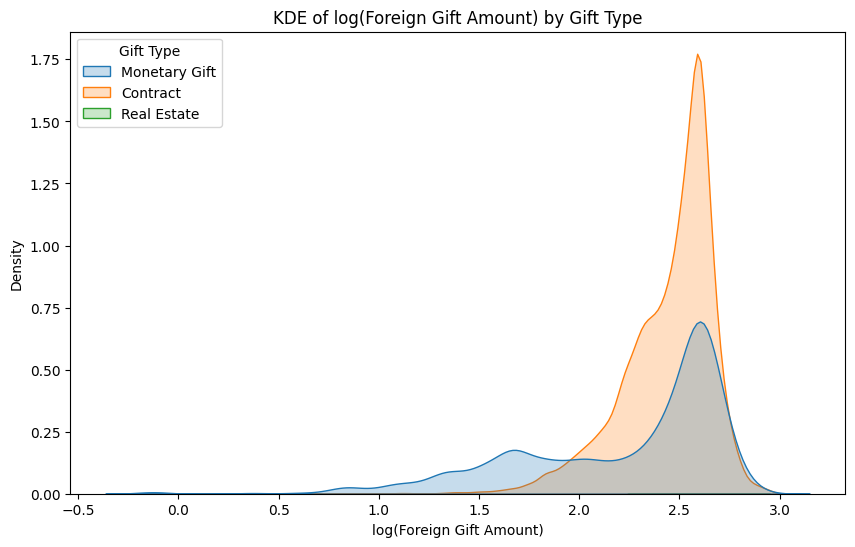


Top 15 Countries by Number of Gifts: Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 Countries by Total Dollar Amount:
 Country of Giftor
ENGLAND                 36809.94
CHINA                   28225.51
CANADA                  21333.70
JAPAN                   20751.40
SAUDI ARABIA            19347.06
SWITZERLAND             19071.61
FRANCE                  15599.09
GERMANY                 14738.06
HONG KONG               12459.74
QATAR                    9321.28
SOUTH KOREA              8399.69
THE NETHERLANDS          5859.72
KOREA                    5493.03
INDIA                    5456.38
UNITED ARAB EMIRATES     4733.28
Name: Foreign G

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fgdf = pd.read_csv('/content/ForeignGifts_edu.csv')

fgdf.head(20)
fgdf.sample(20) #looking at data

#Create Histogram for Foreign Gift Amount
fgdf['Foreign Gift Amount'] = np.arcsinh(fgdf['Foreign Gift Amount']) #arcsin trnasformation to adjust scale
fgdf['Foreign Gift Amount'].hist(bins=20, grid=False)
plt.title('Foreign Gift Amount after Transformation')
plt.xlabel('Foreign Gift Amount')
plt.ylabel('Count')
plt.show()

#Create Histogram for Gift Type
fgdf['Gift Type'].hist(bins=20, grid=False)
plt.title('Gift Type')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.show()

#Proportion of Gift Types
monetary_proportion = ((fgdf['Gift Type'] == 'Monetary Gift').sum() / len(fgdf))
print('\nProportion of Monetary Gifts as a %:', round(monetary_proportion * 100, 2)) #round to 2 decimal places
contract_proportion = ((fgdf['Gift Type'] == 'Contract').sum() / len(fgdf))
print('Proportion of Contract Gifts as a %:', round(contract_proportion * 100, 2)) #round to 2 decimal places
realestate_proportion = ((fgdf['Gift Type'] == 'Real Estate').sum() / len(fgdf))
print('Proportion of Real Estate Gifts as a %:', round(realestate_proportion * 100, 2)) #round to 2 decimal places

#KDE Displays
fgdf['log_amount'] = np.log(fgdf['Foreign Gift Amount'])
plt.figure(figsize=(10,6))
sns.kdeplot(data=fgdf, x='log_amount', fill=True)
plt.title('KDE of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(data=fgdf, x='log_amount', hue='Gift Type', fill=True) #conditional on gift type
plt.title('KDE of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

#Top 15 Giftors by Number of Gifts & Dollar Amount
top15_count = (fgdf.groupby(['Country of Giftor']).size().sort_values(ascending=False).head(15)) #display top 15 countries
print('\nTop 15 Countries by Number of Gifts:', (top15_count))
top15_amount = (fgdf.groupby(['Country of Giftor'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop 15 Countries by Total Dollar Amount:\n', (top15_amount.round(2))) #round to 2 decimal places

#Top Giftors Total
top_giftors = (fgdf.groupby(['Giftor Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop giftors by total amount given:\n', (top_giftors.round(2))) #round to 2 decimal places



The raw 'Foreign Gift Amount' variable is heavily skewed to the right, although it mostly consists of small/moderate donations and a few massive outlier values skew the data. Applying an inverse hyperbolic sine (arcsinh) or logarithmic scale compresses this right tail, revealing a far more symmetric, readable distribution on the graph.

The overall KDE graph indicates distinct clusters of donation sizes. When conditioned on Gift Type, clear patterns emerge: monetary gifts tend to cluster around smaller, lower-value density peaks, whereas contracts and real estate transactions shift heavily toward the higher log values, reflecting significantly larger monetary commitments per gift.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 9874fc1
- **AI tool and model used:** Chat GPT

### *Prompts used

1. I'm completing an assignment for my data science class in which I complete phase 1 on my own, and then use an AI model to revise my work. I'm working in colab and github and using python. I will paste in the instructions for each problem. I have also uploaded the data set I used.

Help me understand 1) any mistakes I made/limitations in my work, 2) how to improve/fix them, and 3) why they need to be fixed.

Instructions:

My code:

Written Descriptions:

2. Provide a concise numbered list of the changes that need to be made, provide only the suggested change, not the reason that it needs to be fixed.

### *AI-proposed changes


Numbered List

1. Q1.2 — Change \(Z=a+bX\) to \(Z=a+bY\).
2. Q1.4 — Fix the counterexample. N=2. Recalculate the means in the counterexample.
3. Q1.4 — Don't claim the equality is “only true when \(g(x)\) is linear.”
4. Q2 — Do not overwrite Foreign Gift Amount with the arcsinh transformation.
5. Q2 - Change the x-axis label on the arcsinh histogram.
5. Q2.2 — Include numerical summary statistics using .describe().
6. Q2.3 — Replace the Gift Type histogram with a value-count table or bar chart.
7. Q2.4 — Calculate log_amount from the original Foreign Gift Amount.
8. Q2.4 — Handle nonpositive gift amounts before taking the logarithm.
9. Q2.4 — Explain how the nonpositive gift amounts were handled.
10. Q2.5 — Recalculate the top 15 countries by total gift amount using the original dollar amounts.
11. Q2.5 — Clearly label the amount ranking as total dollar amounts.
12. Q2.6 — Recalculate the top giftors using the original dollar amounts.
13. Q2 — Preserve original variables and create separate columns for transformations such as log_amount or asinh_amount.
14. Q2 — Correct the comment from “arcsin transformation” to “arcsinh transformation.”


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / **reject** | detected an error in my work that was not there upon checking |
| 2 | **Accept** / modify / reject | accidentally wrote N=3 instead of N=2 |
| 3 | **Accept** / modify / reject | removed statement as it was unnecessary |
| 4 | **Accept** / modify / reject | histogram and top giftor calculations were affected by error |
| 5 |**Accept** / modify / reject|changed x axis label on histogram|
| 6 | **Accept** / modify / reject | supports histogram/strengthens findings on variable  |
| 7 | Accept / modify / **reject** | histogram specified as an option in the instructions |
| 8 | Accept / modify / **reject** | way in which 4 was adressed resolves this issue|
| 9 | **Accept** / modify / reject | was affecting the KDE display|
| 10 | **Accept** / modify / reject | made a comment explaining line of new code|
| 11 | Accept / modify / **reject** | way in which 4 was adressed resolves this issue |
| 12 | Accept / modify / **reject** | unnecessary, already adequately labeled |
| 13 | Accept / modify / **reject** |way in which 4 was adressed resolves this issue |
| 14 | Accept / modify / **reject** | changes already made |
| 15 | **Accept** / modify / reject | correct language|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [21]:
# Your Phase 2 solution to the problem goes here.


[Q1, page 1](https://drive.google.com/file/d/1q4pELHpJ85ZYoxrS3jPakiGhCebBPigD/view)
[Q1, page 2](https://drive.google.com/file/d/1OxgxQ-aDMIlKoPXzjvObgIpuZ9FgBywf/view)

Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64


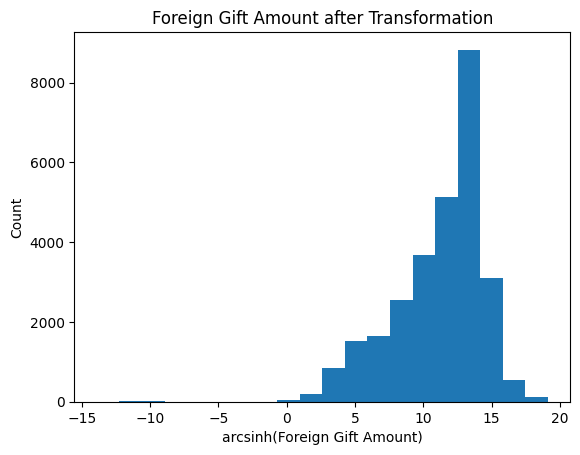

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


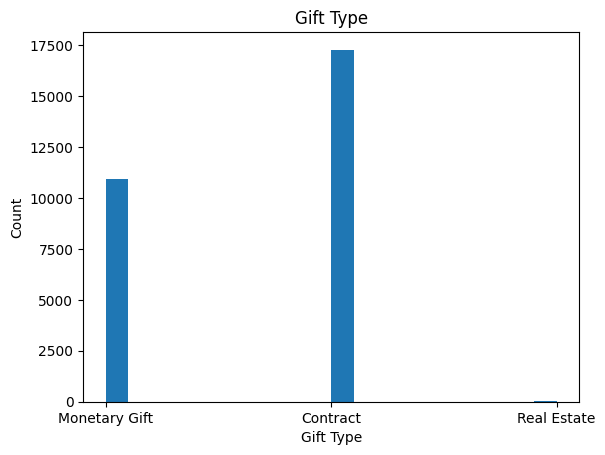


Proportion of Monetary Gifts as a %: 38.75
Proportion of Contract Gifts as a %: 61.21
Proportion of Real Estate Gifts as a %: 0.04


/usr/local/lib/python3.13/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


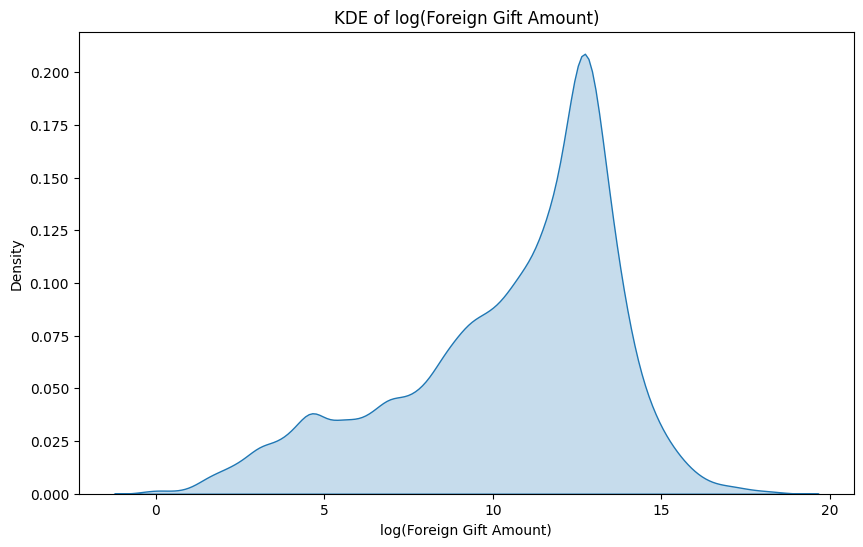

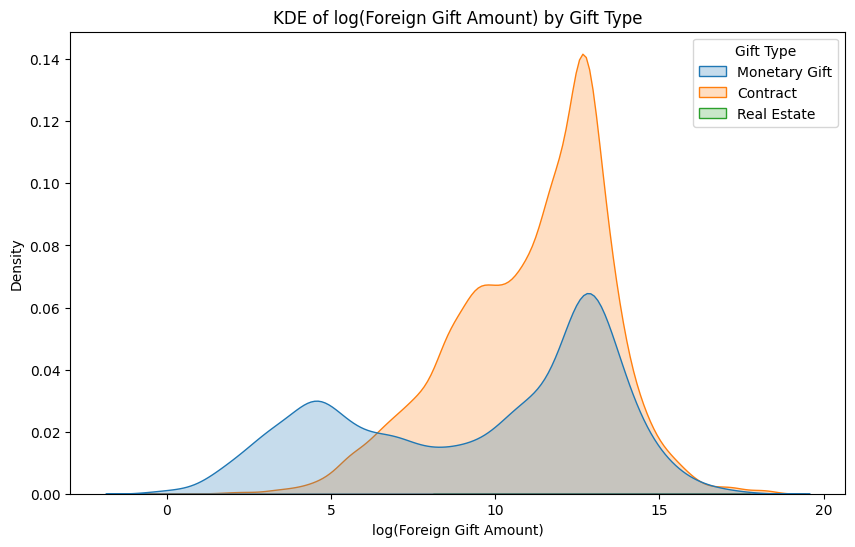


Top 15 Countries by Number of Gifts: Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64

Top 15 Countries by Total Dollar Amount:
 Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA           

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

fgdf = pd.read_csv('/content/ForeignGifts_edu.csv')

fgdf.head(20)
fgdf.sample(20) #looking at data
print(fgdf['Gift Type'].value_counts())

#Create Histogram for Foreign Gift Amount
fgdf['arcsinh_amount'] = np.arcsinh(fgdf['Foreign Gift Amount']) #arcsinh transformation to improve display
fgdf['arcsinh_amount'].hist(bins=20, grid=False)
plt.title('Foreign Gift Amount after Transformation')
plt.xlabel('arcsinh(Foreign Gift Amount)')
plt.ylabel('Count')
plt.show()
print(fgdf['Foreign Gift Amount'].describe())

#Create Histogram for Gift Type
fgdf['Gift Type'].hist(bins=20, grid=False)
plt.title('Gift Type')
plt.xlabel('Gift Type')
plt.ylabel('Count')
plt.show()

#Proportion of Gift Types
monetary_proportion = ((fgdf['Gift Type'] == 'Monetary Gift').sum() / len(fgdf))
print('\nProportion of Monetary Gifts as a %:', round(monetary_proportion * 100, 2)) #round to 2 decimal places
contract_proportion = ((fgdf['Gift Type'] == 'Contract').sum() / len(fgdf))
print('Proportion of Contract Gifts as a %:', round(contract_proportion * 100, 2)) #round to 2 decimal places
realestate_proportion = ((fgdf['Gift Type'] == 'Real Estate').sum() / len(fgdf))
print('Proportion of Real Estate Gifts as a %:', round(realestate_proportion * 100, 2)) #round to 2 decimal places

#KDE Displays
plt.figure(figsize=(10,6))
fgdf['log_amount'] = np.where(
    fgdf['Foreign Gift Amount'] > 0, #only display positive gift amount values
    np.log(fgdf['Foreign Gift Amount']),
    np.nan)
sns.kdeplot(data=fgdf, x='log_amount', fill=True)
plt.title('KDE of log(Foreign Gift Amount)')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

plt.figure(figsize=(10,6))
sns.kdeplot(data=fgdf, x='log_amount', hue='Gift Type', fill=True) #conditional on gift type
plt.title('KDE of log(Foreign Gift Amount) by Gift Type')
plt.xlabel('log(Foreign Gift Amount)')
plt.ylabel('Density')
plt.show()

#Top 15 Giftors by Number of Gifts & Dollar Amount
top15_count = (fgdf.groupby(['Country of Giftor']).size().sort_values(ascending=False).head(15)) #display top 15 countries
print('\nTop 15 Countries by Number of Gifts:', (top15_count))
top15_amount = (fgdf.groupby(['Country of Giftor'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop 15 Countries by Total Dollar Amount:\n', (top15_amount))

#Top Giftors Total
top_giftors = (fgdf.groupby(['Giftor Name'])['Foreign Gift Amount'].sum().sort_values(ascending=False).head(15)) #display top 15 giftors
print('\nTop giftors by total amount given:\n', (top_giftors))

The raw 'Foreign Gift Amount' variable is heavily skewed to the right, although it mostly consists of small/moderate donations and a few massive outlier values skew the data. Applying an inverse hyperbolic sine (arcsinh) or logarithmic scale compresses this right tail, revealing a far more symmetric, readable distribution on the graph.

The overall KDE graph indicates distinct clusters of donation sizes. When conditioned on Gift Type, clear patterns emerge: monetary gifts tend to cluster around smaller, lower-value density peaks, whereas contracts transactions shift heavily toward the higher log values, reflecting significantly larger monetary commitments per gift. Real estate gifts lack enough data to comment on a pattern.

### *Reflection on AI assistance
In your own words without generative AI.

Overall, I found this revision process to be less efficient and more tedious, although still helpful. The AI model detected errors in my work that weren’t there in my written solutions to Q1. Additionally, I found that the numbered list it gave to be less useful (despite prompting it the same way) because it suggested I fix things that were already addressed by the time I reached that number on the list. For example, the error I made with the arcsinh transformation that was addressed as #4 had multiple lingering impacts that, although were immediately resolved when I fixed 4, were still suggested by the model as issues in their own right. That being said, the arcsinh error was the main improvement and now that the issue is addressed, my results are accurate. To decide whether I should accept a change I looked back where the error was in my code, and used reasonable judgment, consulting the class slides when needed. I have no remaining concerns for this assignment.